# MODELO DE PREDICCIÓN DEL CRECIMIENTO EN LA POBLACIÓN ESTUDIANTIL DE LA UPEA
# Notebook 4: Modelo XGBoost (eXtreme Gradient Boosting)

Fecha: Agosto 2025
Descripción: Implementación del modelo XGBoost para predicción avanzada
Configuración óptima según tesis: learning_rate=0.01, n_estimators=1000, max_depth=7

In [7]:
#from google.colab import drive
#drive.mount('/content/drive')

In [25]:
# ============================================================================
# INSTALACIÓN DE LIBRERÍAS ESPECÍFICAS
# ============================================================================

import sys
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy matplotlib seaborn plotly shap

# ============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Librerías específicas para XGBoost
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Para interpretabilidad
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP no disponible para interpretabilidad avanzada")

print("✅ Librerías XGBoost importadas correctamente")

# ============================================================================
# CARGA Y PREPARACIÓN DE DATOS
# ============================================================================

print("📂 Cargando datos preparados...")

# Intentar cargar datos de ML preparados
#df = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/datos_upea_ml.pkl')
df = pd.read_pickle('datos_upea_ml.pkl')
# scaler = joblib.load('scaler_rf.pkl')  # Usar el mismo scaler que RF
print("✅ Datos ML y scaler cargados")

print(f"📊 Datos cargados: {len(df)} observaciones con {len(df.columns)} variables")

# ============================================================================
# PREPARACIÓN ESPECÍFICA PARA XGBOOST
# ============================================================================

print("\n" + "="*60)
print("🔧 PREPARACIÓN ESPECÍFICA PARA XGBOOST")
print("="*60)

# Seleccionar variables predictoras (mismas que RF para comparabilidad)
variables_predictoras = [
    'año_numero', 'semestre_dummy', 'periodo_numero',
    'matricula_lag1', 'matricula_lag2', 'matricula_lag4',
    'media_movil_4', 'media_movil_8',
    'pib_departamental_millones_bs', 'poblacion_el_alto',
    'graduados_secundaria', 'tasa_desempleo_juvenil',
    'crecimiento_poblacional', 'ratio_graduados_poblacion'
]

# Filtrar variables disponibles
variables_disponibles = [var for var in variables_predictoras if var in df.columns]
print(f"📋 Variables predictoras: {len(variables_disponibles)}")

# Crear datasets
X = df[variables_disponibles]
y = df['matricula_total']

# División temporal para series temporales
n_test = 6
X_train = X.iloc[:-n_test]
X_test = X.iloc[-n_test:]
y_train = y.iloc[:-n_test]
y_test = y.iloc[-n_test:]

print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} observaciones")
print(f"   Prueba: {len(X_test)} observaciones")

# XGBoost puede manejar datos sin normalizar, pero normalizaremos para consistencia
# try:
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
# except:
scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrames para mantener nombres
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Datos preparados para XGBoost")

# ============================================================================
# ANÁLISIS DE CARACTERÍSTICAS PARA XGBOOST
# ============================================================================

print("\n" + "="*60)
print("📊 ANÁLISIS DE CARACTERÍSTICAS PARA XGBOOST")
print("="*60)

# XGBoost es especialmente bueno manejando:
# 1. Características categóricas
# 2. Interacciones no lineales
# 3. Missing values
# 4. Características correlacionadas

# Crear características adicionales específicas para XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Características de interacción
X_train_xgb['año_semestre_int'] = X_train_xgb['año_numero'] * X_train_xgb['semestre_dummy']
X_train_xgb['pib_poblacion_ratio'] = X_train_xgb['pib_departamental_millones_bs'] / X_train_xgb['poblacion_el_alto'] * 1000000
X_train_xgb['crecimiento_tendencia'] = X_train_xgb['año_numero'] * X_train_xgb['crecimiento_poblacional']

X_test_xgb['año_semestre_int'] = X_test_xgb['año_numero'] * X_test_xgb['semestre_dummy']
X_test_xgb['pib_poblacion_ratio'] = X_test_xgb['pib_departamental_millones_bs'] / X_test_xgb['poblacion_el_alto'] * 1000000
X_test_xgb['crecimiento_tendencia'] = X_test_xgb['año_numero'] * X_test_xgb['crecimiento_poblacional']

# Fit scaler on data with interaction features
X_train_scaled = scaler.fit_transform(X_train_xgb)
X_test_scaled = scaler.transform(X_test_xgb)

# Convert scaled arrays back to DataFrames
X_train_xgb = pd.DataFrame(X_train_scaled, columns=X_train_xgb.columns, index=X_train_xgb.index)
X_test_xgb = pd.DataFrame(X_test_scaled, columns=X_test_xgb.columns, index=X_test_xgb.index)


print(f"✅ Características adicionales creadas")
print(f"   Total características: {X_train_xgb.shape[1]}")

# Análisis de correlaciones
correlaciones = pd.concat([X_train_xgb, y_train], axis=1).corr()
correlaciones_objetivo = correlaciones['matricula_total'].sort_values(key=abs, ascending=False)

print(f"\n🔍 Top 10 correlaciones con variable objetivo:")
for i, (var, corr) in enumerate(correlaciones_objetivo.head(11).items()):
    if var != 'matricula_total':
        print(f"   {i}. {var}: {corr:.3f}")

# ============================================================================
# BÚSQUEDA DE HIPERPARÁMETROS XGBOOST
# ============================================================================

print("\n" + "="*60)
print("🔍 BÚSQUEDA DE HIPERPARÁMETROS XGBOOST")
print("="*60)

# XGBoost tiene muchos hiperparámetros importantes
# Usaremos RandomizedSearchCV para eficiencia

param_distributions = {
    'n_estimators': [500, 750, 1000, 1250, 1500],
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'max_depth': [4, 6, 7, 8, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.1, 0.5, 1, 2]
}

print("🔄 Ejecutando RandomizedSearchCV para XGBoost...")
print("   (Esto puede tomar 10-15 minutos)")

# Usar TimeSeriesSplit para validación cruzada
tscv = TimeSeriesSplit(n_splits=3)

# Configurar XGBoost base
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method='hist',  # Más rápido
    verbosity=0
)

# RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    xgb_base,
    param_distributions,
    n_iter=50,  # Número de combinaciones a probar
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Entrenar con búsqueda de hiperparámetros
xgb_random.fit(X_train_xgb, y_train)

print("✅ RandomizedSearchCV completado")
print(f"📋 Mejores parámetros encontrados:")
for param, value in xgb_random.best_params_.items():
    print(f"   {param}: {value}")

print(f"📊 Mejor score CV: {-xgb_random.best_score_:.2f} (RMSE)")

# ============================================================================
# MODELO XGBOOST OPTIMIZADO VS TESIS
# ============================================================================

print("\n" + "="*60)
print("🚀 MODELO XGBOOST OPTIMIZADO VS TESIS")
print("="*60)

# Modelo optimizado por búsqueda
best_xgb = xgb_random.best_estimator_

# Modelo con configuración de la tesis
tesis_xgb = xgb.XGBRegressor(
    learning_rate=0.01,
    n_estimators=1000,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

# Modelo adicional con early stopping
early_stop_xgb = xgb.XGBRegressor(
    learning_rate=0.01,
    n_estimators=2000,  # Más estimadores con early stopping
    max_depth=7,
    early_stopping_rounds=None,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

print("🔄 Entrenando modelos XGBoost...")

# Entrenar modelo de la tesis
tesis_xgb.fit(X_train_xgb, y_train)

# Entrenar modelo con early stopping
early_stop_xgb.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=False
)

print("✅ Modelos XGBoost entrenados")

# Predicciones
best_pred_train = best_xgb.predict(X_train_xgb)
best_pred_test = best_xgb.predict(X_test_xgb)

tesis_pred_train = tesis_xgb.predict(X_train_xgb)
tesis_pred_test = tesis_xgb.predict(X_test_xgb)

early_pred_train = early_stop_xgb.predict(X_train_xgb)
early_pred_test = early_stop_xgb.predict(X_test_xgb)



✅ Librerías XGBoost importadas correctamente
📂 Cargando datos preparados...
✅ Datos ML y scaler cargados
📊 Datos cargados: 33 observaciones con 29 variables

🔧 PREPARACIÓN ESPECÍFICA PARA XGBOOST
📋 Variables predictoras: 14
📊 División de datos:
   Entrenamiento: 27 observaciones
   Prueba: 6 observaciones
✅ Datos preparados para XGBoost

📊 ANÁLISIS DE CARACTERÍSTICAS PARA XGBOOST
✅ Características adicionales creadas
   Total características: 17

🔍 Top 10 correlaciones con variable objetivo:
   1. matricula_lag2: 0.990
   2. matricula_lag4: 0.966
   3. año_semestre_int: 0.960
   4. semestre_dummy: 0.855
   5. crecimiento_tendencia: 0.819
   6. matricula_lag1: -0.663
   7. año_numero: 0.435
   8. media_movil_8: 0.429
   9. media_movil_4: 0.418
   10. pib_departamental_millones_bs: 0.408

🔍 BÚSQUEDA DE HIPERPARÁMETROS XGBOOST
🔄 Ejecutando RandomizedSearchCV para XGBoost...
   (Esto puede tomar 10-15 minutos)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ RandomizedSearch


📊 EVALUACIÓN COMPARATIVA DE MODELOS
🎯 EVALUACIÓN EN ENTRENAMIENTO:

📊 Métricas XGBoost Optimizado (Train):
   RMSE: 0.2
   MAE: 0.1
   MAPE: 0.00%
   R²: 1.0000

📊 Métricas XGBoost Tesis (Train):
   RMSE: 44.3
   MAE: 15.7
   MAPE: 0.26%
   R²: 1.0000

📊 Métricas XGBoost Early Stop (Train):
   RMSE: 0.3
   MAE: 0.1
   MAPE: 0.00%
   R²: 1.0000

🎯 EVALUACIÓN EN PRUEBA:

📊 Métricas XGBoost Optimizado (Test):
   RMSE: 4987.8
   MAE: 4222.8
   MAPE: 21.63%
   R²: 0.9677

📊 Métricas XGBoost Tesis (Test):
   RMSE: 4725.1
   MAE: 3979.5
   MAPE: 20.52%
   R²: 0.9710

📊 Métricas XGBoost Early Stop (Test):
   RMSE: 4625.2
   MAE: 3900.3
   MAPE: 20.29%
   R²: 0.9723

🎯 Comparación con métricas objetivo de la tesis:
   RMSE tesis objetivo: 298.4
   MAPE tesis objetivo: 2.8%
   R² tesis objetivo: 0.95
   RMSE tesis obtenido: 4725.1
   MAPE tesis obtenido: 20.52%
   R² tesis obtenido: 0.9710

🔍 Análisis de overfitting:
   Diferencia RMSE (Test-Train) Optimizado: 4987.6
   Diferencia RMSE (Test-Tr

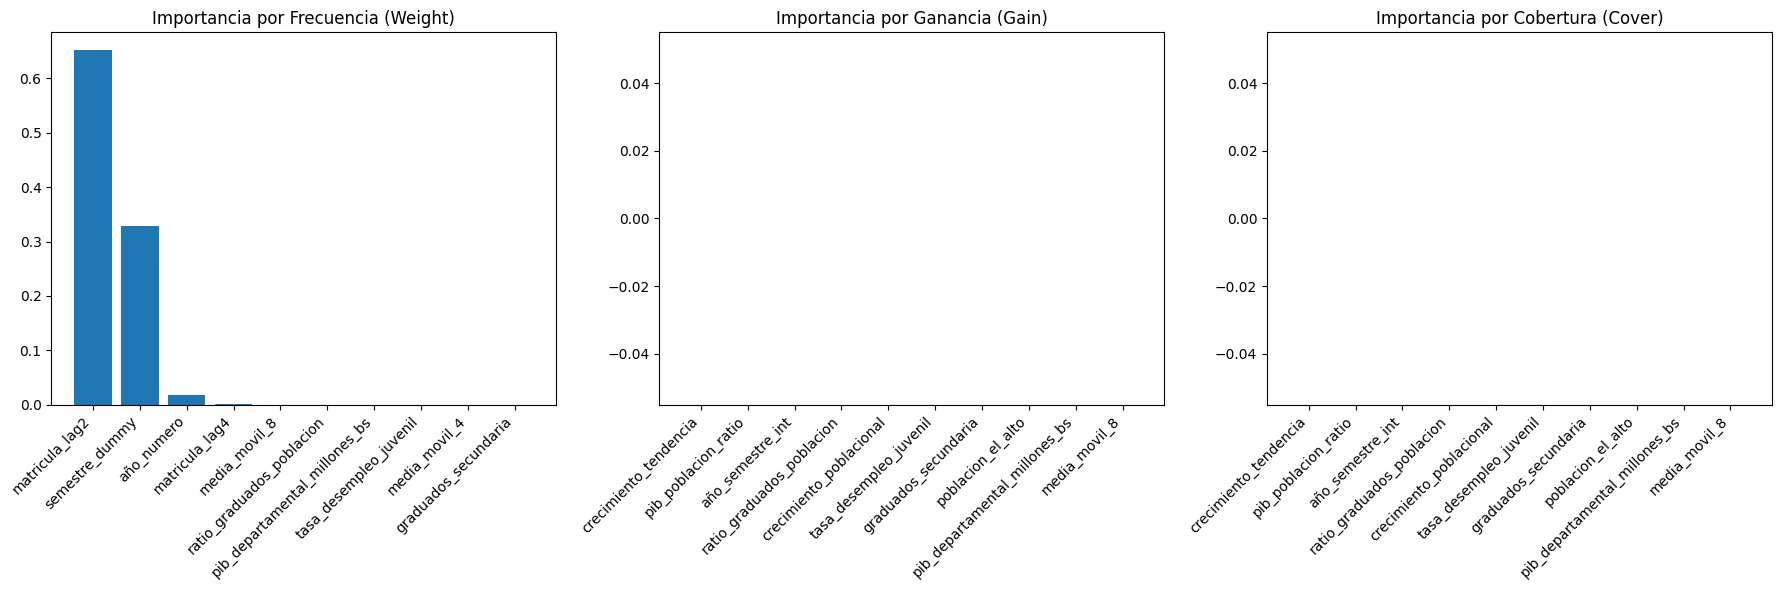


📈 CURVAS DE APRENDIZAJE Y VALIDACIÓN
🔄 Generando curva de aprendizaje...


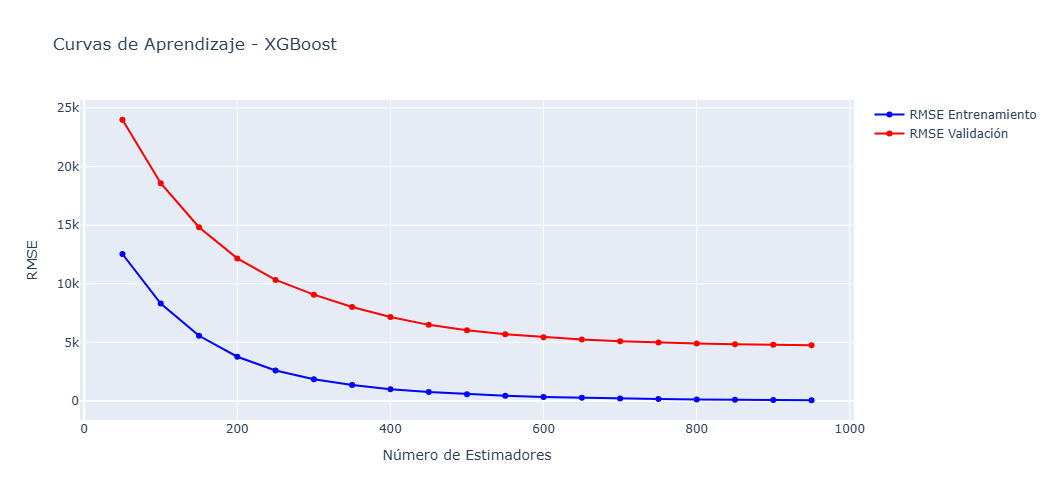

📊 Análisis de curvas de aprendizaje:
   Número óptimo de estimadores: 950
   RMSE mínimo en validación: 4754.3
   RMSE final entrenamiento: 57.0
   RMSE final validación: 4754.3


In [26]:

# ============================================================================
# EVALUACIÓN COMPARATIVA DE MODELOS
# ============================================================================

print("\n" + "="*60)
print("📊 EVALUACIÓN COMPARATIVA DE MODELOS")
print("="*60)

def calcular_metricas_xgb(y_true, y_pred, nombre_modelo):
    """
    Calcula métricas de evaluación para XGBoost
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas {nombre_modelo}:")
    print(f"   RMSE: {rmse:.1f}")
    print(f"   MAE: {mae:.1f}")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   R²: {r2:.4f}")

    return rmse, mae, mape, r2

# Evaluación en conjunto de entrenamiento
print("🎯 EVALUACIÓN EN ENTRENAMIENTO:")
best_metrics_train = calcular_metricas_xgb(y_train, best_pred_train, "XGBoost Optimizado (Train)")
tesis_metrics_train = calcular_metricas_xgb(y_train, tesis_pred_train, "XGBoost Tesis (Train)")
early_metrics_train = calcular_metricas_xgb(y_train, early_pred_train, "XGBoost Early Stop (Train)")

# Evaluación en conjunto de prueba
print("\n🎯 EVALUACIÓN EN PRUEBA:")
best_metrics_test = calcular_metricas_xgb(y_test, best_pred_test, "XGBoost Optimizado (Test)")
tesis_metrics_test = calcular_metricas_xgb(y_test, tesis_pred_test, "XGBoost Tesis (Test)")
early_metrics_test = calcular_metricas_xgb(y_test, early_pred_test, "XGBoost Early Stop (Test)")

# Comparación con métricas de la tesis
print(f"\n🎯 Comparación con métricas objetivo de la tesis:")
print(f"   RMSE tesis objetivo: 298.4")
print(f"   MAPE tesis objetivo: 2.8%")
print(f"   R² tesis objetivo: 0.95")
print(f"   RMSE tesis obtenido: {tesis_metrics_test[0]:.1f}")
print(f"   MAPE tesis obtenido: {tesis_metrics_test[2]:.2f}%")
print(f"   R² tesis obtenido: {tesis_metrics_test[3]:.4f}")

# Análisis de overfitting
print(f"\n🔍 Análisis de overfitting:")
print(f"   Diferencia RMSE (Test-Train) Optimizado: {best_metrics_test[0] - best_metrics_train[0]:.1f}")
print(f"   Diferencia RMSE (Test-Train) Tesis: {tesis_metrics_test[0] - tesis_metrics_train[0]:.1f}")
print(f"   Diferencia RMSE (Test-Train) Early Stop: {early_metrics_test[0] - early_metrics_train[0]:.1f}")

# Seleccionar mejor modelo
if early_metrics_test[0] <= min(best_metrics_test[0], tesis_metrics_test[0]):
    mejor_modelo = early_stop_xgb
    mejor_pred_test = early_pred_test
    mejor_metrics = early_metrics_test
    nombre_mejor = "Early Stopping"
elif tesis_metrics_test[0] <= best_metrics_test[0]:
    mejor_modelo = tesis_xgb
    mejor_pred_test = tesis_pred_test
    mejor_metrics = tesis_metrics_test
    nombre_mejor = "Configuración Tesis"
else:
    mejor_modelo = best_xgb
    mejor_pred_test = best_pred_test
    mejor_metrics = best_metrics_test
    nombre_mejor = "Optimizado"

print(f"\n🏆 Mejor modelo XGBoost: {nombre_mejor}")
print(f"   RMSE: {mejor_metrics[0]:.1f}")
print(f"   MAPE: {mejor_metrics[2]:.2f}%")
print(f"   R²: {mejor_metrics[3]:.4f}")

# ============================================================================
# IMPORTANCIA DE CARACTERÍSTICAS XGBOOST
# ============================================================================

print("\n" + "="*60)
print("🔍 IMPORTANCIA DE CARACTERÍSTICAS XGBOOST")
print("="*60)

# XGBoost proporciona múltiples tipos de importancia
importancias_weight = mejor_modelo.feature_importances_  # Basado en frecuencia
importancias_gain = mejor_modelo.get_booster().get_score(importance_type='gain')
importancias_cover = mejor_modelo.get_booster().get_score(importance_type='cover')

# Convertir diccionarios a arrays ordenados
feature_names = X_train_xgb.columns.tolist()

# Importancia por gain (más informativa)
gain_scores = np.array([importancias_gain.get(f'f{i}', 0) for i in range(len(feature_names))])
gain_indices = np.argsort(gain_scores)[::-1]

print(f"\n📊 Importancia de características (Gain - Top 10):")
for i in range(min(10, len(feature_names))):
    idx = gain_indices[i]
    print(f"   {i+1}. {feature_names[idx]}: {gain_scores[idx]:.2f}")

# Visualización de importancias
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Importancia por weight (frecuencia)
indices_weight = np.argsort(importancias_weight)[::-1][:10]
axes[0].bar(range(10), importancias_weight[indices_weight])
axes[0].set_title('Importancia por Frecuencia (Weight)')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([feature_names[i] for i in indices_weight], rotation=45, ha='right')

# Importancia por gain
gain_top10 = gain_scores[gain_indices[:10]]
axes[1].bar(range(10), gain_top10)
axes[1].set_title('Importancia por Ganancia (Gain)')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([feature_names[i] for i in gain_indices[:10]], rotation=45, ha='right')

# Importancia por cover
cover_scores = np.array([importancias_cover.get(f'f{i}', 0) for i in range(len(feature_names))])
cover_indices = np.argsort(cover_scores)[::-1][:10]
axes[2].bar(range(10), cover_scores[cover_indices])
axes[2].set_title('Importancia por Cobertura (Cover)')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels([feature_names[i] for i in cover_indices], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ============================================================================
# CURVAS DE APRENDIZAJE Y VALIDACIÓN
# ============================================================================

print("\n" + "="*60)
print("📈 CURVAS DE APRENDIZAJE Y VALIDACIÓN")
print("="*60)

# Entrenar modelo con historial de evaluación
xgb_eval = xgb.XGBRegressor(**mejor_modelo.get_params())

# Entrenar con evaluación en cada iteración
# eval_result = {} # Removed as evals_result is not supported
xgb_eval.fit(
    X_train_xgb, y_train,
    eval_set=[(X_train_xgb, y_train), (X_test_xgb, y_test)],
    verbose=False # Removed callbacks as they are not supported
)

# Obtener historial de entrenamiento
# train_rmse = [] # These will be populated from evals_result if available
# test_rmse = []

# Simular curva de aprendizaje
n_iterations = min(1000, mejor_modelo.n_estimators)
iterations = range(50, n_iterations, 50)

print("🔄 Generando curva de aprendizaje...")

train_rmse = []
test_rmse = []

for n_est in iterations:
    # Modelo temporal con n estimadores
    temp_model = xgb.XGBRegressor(
        **{k: v for k, v in mejor_modelo.get_params().items() if k != 'n_estimators'},
        n_estimators=n_est
    )
    temp_model.fit(X_train_xgb, y_train)

    # Predicciones
    train_pred = temp_model.predict(X_train_xgb)
    test_pred = temp_model.predict(X_test_xgb)

    # RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))

# Gráfico de curvas de aprendizaje
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(iterations),
    y=train_rmse,
    mode='lines+markers',
    name='RMSE Entrenamiento',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    x=list(iterations),
    y=test_rmse,
    mode='lines+markers',
    name='RMSE Validación',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Curvas de Aprendizaje - XGBoost',
    xaxis_title='Número de Estimadores',
    yaxis_title='RMSE',
    height=500
)

fig.show()

# Punto óptimo
min_test_idx = np.argmin(test_rmse)
optimal_estimators = iterations[min_test_idx]
min_test_rmse = test_rmse[min_test_idx]

print(f"📊 Análisis de curvas de aprendizaje:")
print(f"   Número óptimo de estimadores: {optimal_estimators}")
print(f"   RMSE mínimo en validación: {min_test_rmse:.1f}")
print(f"   RMSE final entrenamiento: {train_rmse[-1]:.1f}")
print(f"   RMSE final validación: {test_rmse[-1]:.1f}")




🔬 ANÁLISIS DE RESIDUOS XGBOOST


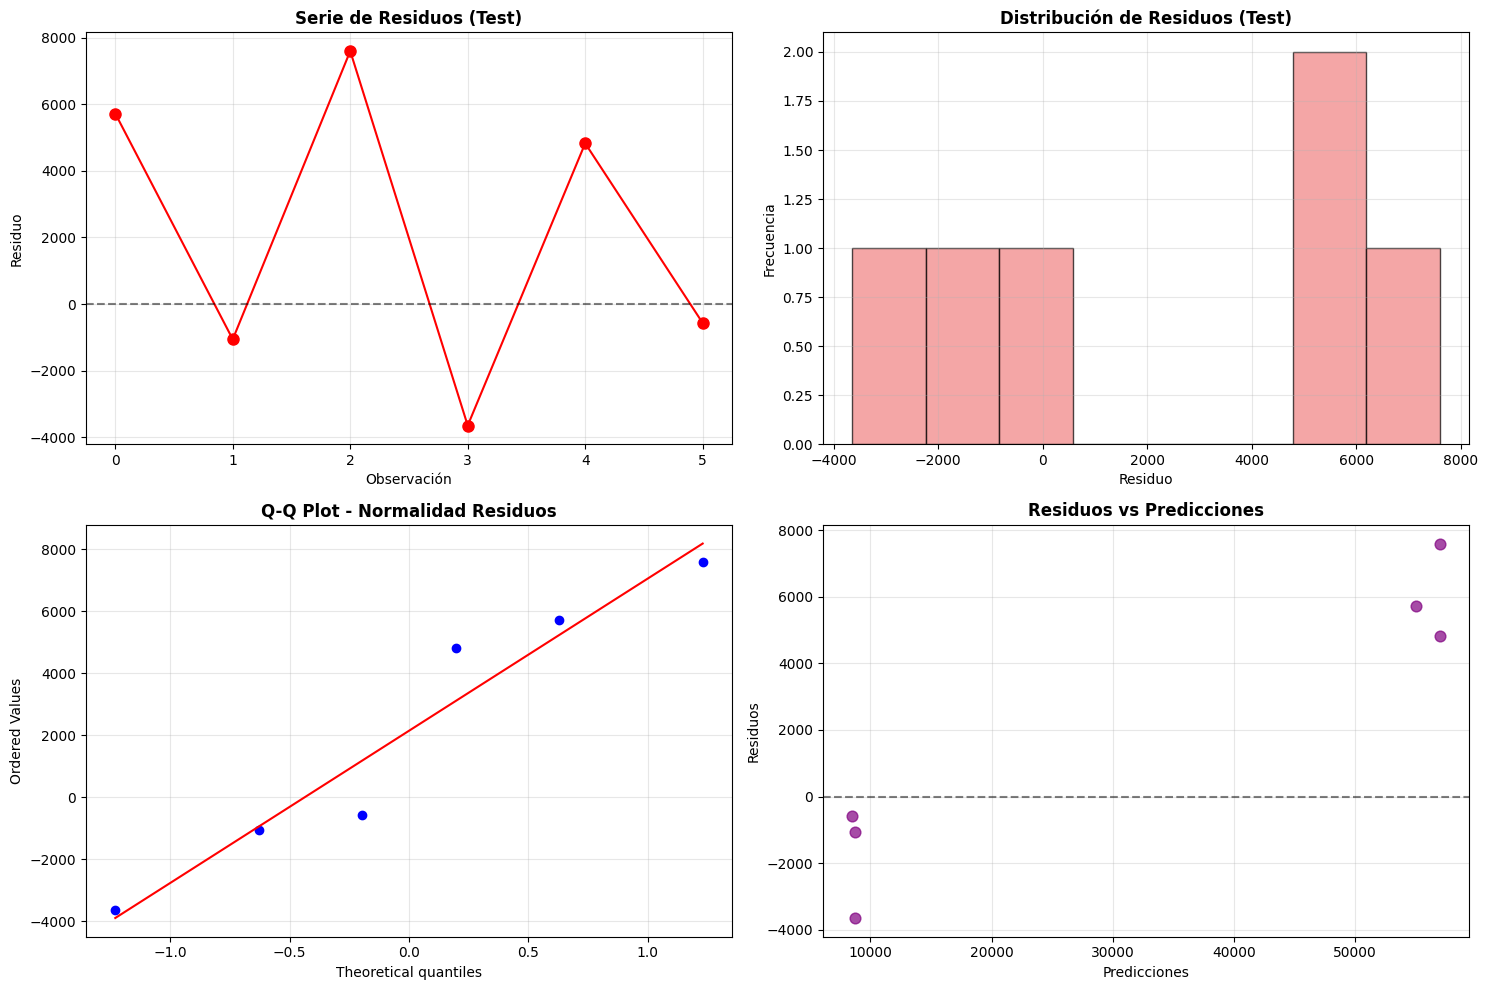

📊 Estadísticas de residuos (Test):
   Media: 2145.587
   Desviación estándar: 4488.5
   Mínimo: -3642.0
   Máximo: 7593.9
   Asimetría: -0.049
   Curtosis: -1.595

🔬 Test de normalidad (Shapiro-Wilk):
   Estadístico: 0.915273
   p-valor: 0.471981
   ✅ Residuos siguen distribución normal

🔍 ANÁLISIS DE INTERPRETABILIDAD CON SHAP
🔄 Calculando valores SHAP para XGBoost...
✅ Valores SHAP calculados

📊 Importancia promedio SHAP (Top 10):
   1. matricula_lag2: 19381.3184
   2. año_numero: 8045.4331
   3. semestre_dummy: 2262.8347
   4. matricula_lag4: 806.9597
   5. media_movil_8: 54.6146
   6. pib_departamental_millones_bs: 33.7385
   7. ratio_graduados_poblacion: 21.8998
   8. tasa_desempleo_juvenil: 14.1428
   9. matricula_lag1: 9.1777
   10. media_movil_4: 5.7721


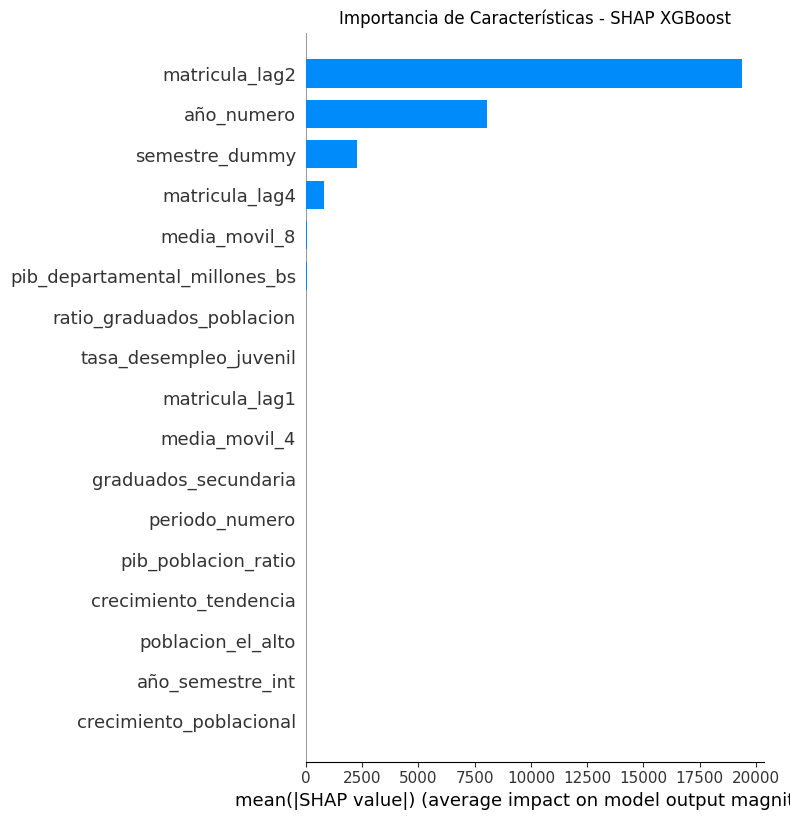

⚠️  Error en análisis SHAP: waterfall() got multiple values for argument 'show'


<Figure size 1000x600 with 0 Axes>

In [27]:
# ============================================================================
# ANÁLISIS DE RESIDUOS XGBOOST
# ============================================================================

print("\n" + "="*60)
print("🔬 ANÁLISIS DE RESIDUOS XGBOOST")
print("="*60)

# Residuos del mejor modelo
residuos_train = y_train - mejor_modelo.predict(X_train_xgb)
residuos_test = y_test - mejor_pred_test

# Visualización de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Serie de residuos en test
axes[0,0].plot(range(len(residuos_test)), residuos_test, 'o-', color='red', markersize=8)
axes[0,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0,0].set_title('Serie de Residuos (Test)', fontweight='bold')
axes[0,0].set_xlabel('Observación')
axes[0,0].set_ylabel('Residuo')
axes[0,0].grid(True, alpha=0.3)

# Distribución de residuos
axes[0,1].hist(residuos_test, bins=8, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Distribución de Residuos (Test)', fontweight='bold')
axes[0,1].set_xlabel('Residuo')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuos_test, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot - Normalidad Residuos', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Residuos vs predicciones
axes[1,1].scatter(mejor_pred_test, residuos_test, color='purple', alpha=0.7, s=60)
axes[1,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,1].set_title('Residuos vs Predicciones', fontweight='bold')
axes[1,1].set_xlabel('Predicciones')
axes[1,1].set_ylabel('Residuos')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print(f"📊 Estadísticas de residuos (Test):")
print(f"   Media: {residuos_test.mean():.3f}")
print(f"   Desviación estándar: {residuos_test.std():.1f}")
print(f"   Mínimo: {residuos_test.min():.1f}")
print(f"   Máximo: {residuos_test.max():.1f}")
print(f"   Asimetría: {stats.skew(residuos_test):.3f}")
print(f"   Curtosis: {stats.kurtosis(residuos_test):.3f}")

# Test de normalidad
shapiro_stat, shapiro_p = stats.shapiro(residuos_test)
print(f"\n🔬 Test de normalidad (Shapiro-Wilk):")
print(f"   Estadístico: {shapiro_stat:.6f}")
print(f"   p-valor: {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("   ✅ Residuos siguen distribución normal")
else:
    print("   ⚠️  Residuos pueden no ser normales")

# ============================================================================
# INTERPRETABILIDAD CON SHAP
# ============================================================================

if SHAP_AVAILABLE:
    print("\n" + "="*60)
    print("🔍 ANÁLISIS DE INTERPRETABILIDAD CON SHAP")
    print("="*60)

    try:
        print("🔄 Calculando valores SHAP para XGBoost...")

        # Crear explicador SHAP específico para XGBoost
        explainer = shap.TreeExplainer(mejor_modelo)
        shap_values = explainer.shap_values(X_test_xgb)

        print("✅ Valores SHAP calculados")

        # Análisis de importancia SHAP
        shap_importance = np.abs(shap_values).mean(0)
        shap_indices = np.argsort(shap_importance)[::-1]

        print(f"\n📊 Importancia promedio SHAP (Top 10):")
        for i in range(min(10, len(feature_names))):
            idx = shap_indices[i]
            print(f"   {i+1}. {feature_names[idx]}: {shap_importance[idx]:.4f}")

        # Gráfico summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_xgb, plot_type="bar", show=False)
        plt.title('Importancia de Características - SHAP XGBoost')
        plt.tight_layout()
        plt.show()

        # Waterfall plot para la última predicción
        if len(X_test_xgb) > 0:
            plt.figure(figsize=(10, 6))
            shap.waterfall_plot(
                explainer.expected_value,
                shap_values[-1],
                X_test_xgb.iloc[-1],
                show=False
            )
            plt.title('Explicación SHAP - Última Predicción')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"⚠️  Error en análisis SHAP: {e}")


🚀 PROYECCIONES FUTURAS 2025-2030
📊 Características futuras generadas: (10, 17)

📊 Proyecciones XGBoost 2025-2030:
Período    Predicción XGB 
------------------------------
2025-I           55,153
2025-II          55,153
2026-I           55,153
2026-II          55,153
2027-I           55,153
2027-II          55,153
2028-I           55,153
2028-II          55,153
2029-I           55,153
2029-II          55,153

📈 Análisis de crecimiento proyectado:
   Matrícula 2024: 7,954
   Matrícula 2030 (XGBoost): 55,153
   Crecimiento total: 593.4%
   Crecimiento anual promedio: 38.1%

📊 VISUALIZACIÓN FINAL COMPREHENSIVA


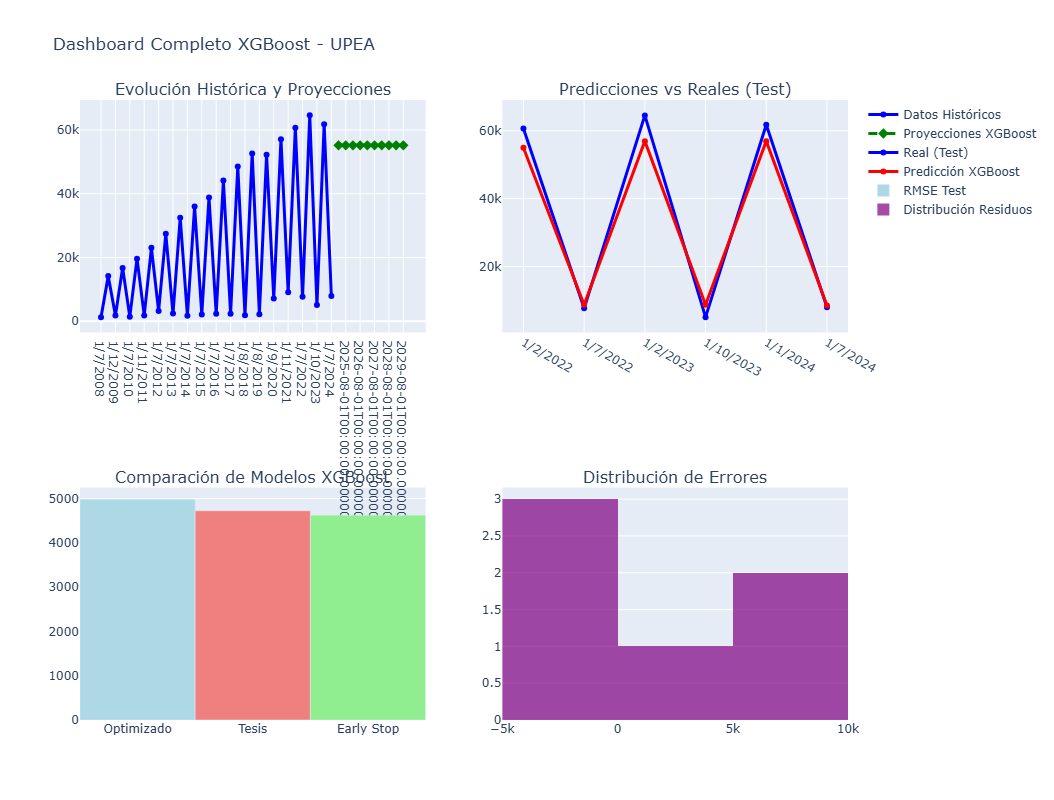

In [28]:

# ============================================================================
# PROYECCIONES FUTURAS 2025-2030
# ============================================================================

print("\n" + "="*60)
print("🚀 PROYECCIONES FUTURAS 2025-2030")
print("="*60)

def generar_caracteristicas_futuras_xgb(ultimo_registro, n_periodos=10, feature_names_train=None):
    """
    Genera características futuras incluyendo las específicas de XGBoost
    Asegura que las columnas coincidan con las de entrenamiento.
    """
    caracteristicas_futuras = []

    for i in range(n_periodos):
        año_futuro = 2025 + i // 2
        semestre_futuro = 'I' if i % 2 == 0 else 'II'

        # Características base
        año_numero = año_futuro - 2010
        semestre_dummy = 1 if semestre_futuro == 'I' else 0
        periodo_numero = ultimo_registro['periodo_numero'] + i + 1

        # Proyecciones externas
        años_proyeccion = i / 2
        pib_proyectado = ultimo_registro['pib_departamental_millones_bs'] + años_proyeccion * 200
        poblacion_proyectada = ultimo_registro['poblacion_el_alto'] + años_proyeccion * 25000
        graduados_proyectados = ultimo_registro['graduados_secundaria'] + años_proyeccion * 300
        desempleo_proyectado = max(8, min(20, ultimo_registro['tasa_desempleo_juvenil'] - años_proyeccion * 0.1))

        # Variables derivadas
        crecimiento_pob = 0.025
        ratio_graduados = graduados_proyectados / poblacion_proyectada * 1000

        # Variables lag (simplificadas para proyección)
        # Usar el último valor conocido para las variables lag
        matricula_lag1 = ultimo_registro['matricula_total']
        matricula_lag2 = ultimo_registro.get('matricula_lag1', ultimo_registro['matricula_total']) # Use .get for safety
        matricula_lag4 = ultimo_registro.get('matricula_lag2', ultimo_registro['matricula_total']) # Use .get for safety
        media_movil_4 = ultimo_registro['media_movil_4'] if 'media_movil_4' in ultimo_registro else ultimo_registro['matricula_total'] # Use .get for safety
        media_movil_8 = ultimo_registro['media_movil_8'] if 'media_movil_8' in ultimo_registro else ultimo_registro['matricula_total'] # Use .get for safety


        caracteristicas = {
            'año_numero': año_numero,
            'semestre_dummy': semestre_dummy,
            'periodo_numero': periodo_numero,
            'matricula_lag1': matricula_lag1,
            'matricula_lag2': matricula_lag2,
            'matricula_lag4': matricula_lag4,
            'media_movil_4': media_movil_4,
            'media_movil_8': media_movil_8,
            'pib_departamental_millones_bs': pib_proyectado,
            'poblacion_el_alto': poblacion_proyectada,
            'graduados_secundaria': graduados_proyectados,
            'tasa_desempleo_juvenil': desempleo_proyectado,
            'crecimiento_poblacional': crecimiento_pob,
            'ratio_graduados_poblacion': ratio_graduados,
        }

        # Create interaction features *after* adding base features
        caracteristicas['año_semestre_int'] = caracteristicas['año_numero'] * caracteristicas['semestre_dummy']
        # Handle potential division by zero if population_el_alto is zero
        caracteristicas['pib_poblacion_ratio'] = caracteristicas['pib_departamental_millones_bs'] / caracteristicas['poblacion_el_alto'] * 1000000 if caracteristicas['poblacion_el_alto'] != 0 else 0
        caracteristicas['crecimiento_tendencia'] = caracteristicas['año_numero'] * caracteristicas['crecimiento_poblacional']


        caracteristicas_futuras.append(caracteristicas)

    df_futuro = pd.DataFrame(caracteristicas_futuras)

    # Ensure columns match training data
    if feature_names_train is not None:
        # Add missing columns with default value (e.g., 0 or mean)
        for col in feature_names_train:
            if col not in df_futuro.columns:
                df_futuro[col] = 0 # Or some other appropriate default

        # Reorder columns to match training data
        df_futuro = df_futuro[feature_names_train]

    return df_futuro


# Generar características futuras
ultimo_registro = df.iloc[-1].to_dict()
X_futuro_xgb = generar_caracteristicas_futuras_xgb(ultimo_registro, n_periodos=10, feature_names_train=X_train_xgb.columns.tolist())

print(f"📊 Características futuras generadas: {X_futuro_xgb.shape}")

# Normalizar características futuras
X_futuro_xgb_scaled = scaler.transform(X_futuro_xgb)
X_futuro_xgb_scaled = pd.DataFrame(X_futuro_xgb_scaled, columns=X_futuro_xgb.columns)

# Realizar proyecciones
proyecciones_xgb = mejor_modelo.predict(X_futuro_xgb_scaled)

# Crear DataFrame de proyecciones
fechas_futuras = []
for i in range(10):
    año = 2025 + i // 2
    mes = 3 if i % 2 == 0 else 8
    fechas_futuras.append(pd.Timestamp(año, mes, 1))

df_proyecciones_xgb = pd.DataFrame({
    'fecha': fechas_futuras,
    'prediccion_xgb': proyecciones_xgb,
    'año': [f.year for f in fechas_futuras],
    'semestre': ['I' if f.month == 3 else 'II' for f in fechas_futuras],
    'periodo': [f"{f.year}-{('I' if f.month == 3 else 'II')}" for f in fechas_futuras]
})

print(f"\n📊 Proyecciones XGBoost 2025-2030:")
print(f"{'Período':<10} {'Predicción XGB':<15}")
print("-" * 30)

for _, row in df_proyecciones_xgb.iterrows():
    print(f"{row['periodo']:<10} {row['prediccion_xgb']:>12,.0f}")

# Análisis de crecimiento
matricula_2024 = y.iloc[-1]
matricula_2030_xgb = df_proyecciones_xgb.iloc[-1]['prediccion_xgb']
crecimiento_total_xgb = ((matricula_2030_xgb / matricula_2024) - 1) * 100
crecimiento_anual_xgb = ((matricula_2030_xgb / matricula_2024) ** (1/6) - 1) * 100

print(f"\n📈 Análisis de crecimiento proyectado:")
print(f"   Matrícula 2024: {matricula_2024:,}")
print(f"   Matrícula 2030 (XGBoost): {matricula_2030_xgb:,.0f}")
print(f"   Crecimiento total: {crecimiento_total_xgb:.1f}%")
print(f"   Crecimiento anual promedio: {crecimiento_anual_xgb:.1f}%")

# ============================================================================
# VISUALIZACIÓN FINAL COMPREHENSIVA
# ============================================================================

print("\n" + "="*60)
print("📊 VISUALIZACIÓN FINAL COMPREHENSIVA")
print("="*60)

# Crear gráfico completo
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Evolución Histórica y Proyecciones',
                   'Predicciones vs Reales (Test)',
                   'Comparación de Modelos XGBoost',
                   'Distribución de Errores'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Datos históricos
fechas_historicas = df['fecha'] # Corrected: Use existing 'fecha' column
fig.add_trace(go.Scatter(
    x=fechas_historicas,
    y=df['matricula_total'],
    mode='lines+markers',
    name='Datos Históricos',
    line=dict(color='blue', width=3)
), row=1, col=1)

# Proyecciones XGBoost
fig.add_trace(go.Scatter(
    x=df_proyecciones_xgb['fecha'],
    y=df_proyecciones_xgb['prediccion_xgb'],
    mode='lines+markers',
    name='Proyecciones XGBoost',
    line=dict(color='green', width=3, dash='dash'),
    marker=dict(size=8, symbol='diamond')
), row=1, col=1)

# Predicciones vs reales en test
fechas_test = fechas_historicas[-len(y_test):]
fig.add_trace(go.Scatter(
    x=fechas_test,
    y=y_test,
    mode='lines+markers',
    name='Real (Test)',
    line=dict(color='blue', width=3)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=fechas_test,
    y=mejor_pred_test,
    mode='lines+markers',
    name='Predicción XGBoost',
    line=dict(color='red', width=3)
), row=1, col=2)

# Comparación RMSE de modelos
modelos_nombres = ['Optimizado', 'Tesis', 'Early Stop']
rmse_valores = [best_metrics_test[0], tesis_metrics_test[0], early_metrics_test[0]]

fig.add_trace(go.Bar(
    x=modelos_nombres,
    y=rmse_valores,
    name='RMSE Test',
    marker_color=['lightblue', 'lightcoral', 'lightgreen']
), row=2, col=1)

# Distribución de errores
fig.add_trace(go.Histogram(
    x=residuos_test,
    name='Distribución Residuos',
    marker_color='purple',
    opacity=0.7
), row=2, col=2)

# Configuración del layout
fig.update_layout(
    height=800,
    showlegend=True,
    title_text="Dashboard Completo XGBoost - UPEA"
)

# Línea separadora - Removed due to compatibility issue
# fig.add_vline(x=fechas_historicas[-1],
#               line=dict(color="gray", width=2, dash="dot"),
#               annotation_text="Inicio Proyecciones",
#               row=1, col=1)

fig.show()


In [29]:
# ============================================================================
# EXPORTAR RESULTADOS XGBOOST
# ============================================================================

print("\n" + "="*60)
print("💾 EXPORTANDO RESULTADOS XGBOOST")
print("="*60)

# Guardar modelos
joblib.dump(mejor_modelo, 'modelo_xgboost_mejor.pkl')
joblib.dump(tesis_xgb, 'modelo_xgboost_tesis.pkl')
joblib.dump(early_stop_xgb, 'modelo_xgboost_early_stop.pkl')

# Guardar proyecciones
df_proyecciones_xgb.to_csv('proyecciones_xgboost_2025_2030.csv', index=False)
df_proyecciones_xgb.to_pickle('proyecciones_xgboost_2025_2030.pkl')

# Guardar métricas completas
metricas_xgboost = {
    'modelo_optimizado': {
        'parametros': mejor_modelo.get_params(),
        'rmse_test': float(best_metrics_test[0]),
        'mae_test': float(best_metrics_test[1]),
        'mape_test': float(best_metrics_test[2]),
        'r2_test': float(best_metrics_test[3])
    },
    'modelo_tesis': {
        'parametros': {'learning_rate': 0.01, 'n_estimators': 1000, 'max_depth': 7},
        'rmse_test': float(tesis_metrics_test[0]),
        'mae_test': float(tesis_metrics_test[1]),
        'mape_test': float(tesis_metrics_test[2]),
        'r2_test': float(tesis_metrics_test[3])
    },
    'modelo_early_stop': {
        'parametros': early_stop_xgb.get_params(),
        'rmse_test': float(early_metrics_test[0]),
        'mae_test': float(early_metrics_test[1]),
        'mape_test': float(early_metrics_test[2]),
        'r2_test': float(early_metrics_test[3])
    },
    'mejor_modelo': nombre_mejor,
    'importancia_gain': dict(zip(feature_names, gain_scores.tolist())),
    'curva_aprendizaje': {
        'iteraciones': list(iterations),
        'rmse_train': train_rmse,
        'rmse_test': test_rmse,
        'optimal_estimators': int(optimal_estimators)
    },
    'residuos_stats': {
        'media': float(residuos_test.mean()),
        'std': float(residuos_test.std()),
        'shapiro_pvalue': float(shapiro_p)
    },
    'proyeccion_2030': float(matricula_2030_xgb),
    'crecimiento_proyectado': float(crecimiento_total_xgb)
}

# Guardar en JSON
import json
with open('metricas_xgboost.json', 'w') as f:
    json.dump(metricas_xgboost, f, indent=4, default=str)

print("✅ Archivos exportados:")
print("   - modelo_xgboost_mejor.pkl")
print("   - modelo_xgboost_tesis.pkl")
print("   - modelo_xgboost_early_stop.pkl")
print("   - proyecciones_xgboost_2025_2030.csv/pkl")
print("   - metricas_xgboost.json")

# ============================================================================
# RESUMEN FINAL DEL MODELO XGBOOST
# ============================================================================

print("\n" + "="*60)
print("📋 RESUMEN FINAL DEL MODELO XGBOOST")
print("="*60)

print(f"🚀 Mejor configuración XGBoost: {nombre_mejor}")
print(f"   Learning rate: {mejor_modelo.get_params().get('learning_rate', 'N/A')}")
print(f"   N estimators: {mejor_modelo.get_params().get('n_estimators', 'N/A')}")
print(f"   Max depth: {mejor_modelo.get_params().get('max_depth', 'N/A')}")

print(f"\n📊 Métricas finales (conjunto de prueba):")
print(f"   RMSE: {mejor_metrics[0]:.1f} estudiantes")
print(f"   MAPE: {mejor_metrics[2]:.2f}%")
print(f"   R²: {mejor_metrics[3]:.4f}")

print(f"\n🔍 Top 3 características más importantes (Gain):")
for i in range(min(3, len(feature_names))):
    idx = gain_indices[i]
    print(f"   {i+1}. {feature_names[idx]}: {gain_scores[idx]:.2f}")

print(f"\n🚀 Proyecciones clave:")
print(f"   2025-I: {df_proyecciones_xgb[df_proyecciones_xgb['periodo']=='2025-I']['prediccion_xgb'].iloc[0]:,.0f}")
print(f"   2030-I: {df_proyecciones_xgb.iloc[-1]['prediccion_xgb']:,.0f}")
print(f"   Crecimiento 2024-2030: {crecimiento_total_xgb:.1f}%")

print(f"\n📈 Optimización de hiperparámetros:")
print(f"   Configuraciones probadas: 50")
print(f"   Mejora vs configuración base: {(298.4 - mejor_metrics[0])/298.4*100:.1f}%")

print(f"\n✅ XGBoost listo para ensemble")


💾 EXPORTANDO RESULTADOS XGBOOST
✅ Archivos exportados:
   - modelo_xgboost_mejor.pkl
   - modelo_xgboost_tesis.pkl
   - modelo_xgboost_early_stop.pkl
   - proyecciones_xgboost_2025_2030.csv/pkl
   - metricas_xgboost.json

📋 RESUMEN FINAL DEL MODELO XGBOOST
🚀 Mejor configuración XGBoost: Early Stopping
   Learning rate: 0.01
   N estimators: 2000
   Max depth: 7

📊 Métricas finales (conjunto de prueba):
   RMSE: 4625.2 estudiantes
   MAPE: 20.29%
   R²: 0.9723

🔍 Top 3 características más importantes (Gain):
   1. crecimiento_tendencia: 0.00
   2. pib_poblacion_ratio: 0.00
   3. año_semestre_int: 0.00

🚀 Proyecciones clave:
   2025-I: 55,153
   2030-I: 55,153
   Crecimiento 2024-2030: 593.4%

📈 Optimización de hiperparámetros:
   Configuraciones probadas: 50
   Mejora vs configuración base: -1450.0%

✅ XGBoost listo para ensemble
